# DSC 680: Project 3

## Predicting Medical Insurance Costs Using Machine Learning

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load dataset
df = pd.read_csv("insurance.csv")

# Basic exploration
print(df.info())
print(df.describe())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Exploratory Data Analysis(EDA) - We visualize the target variable (charges) and examine how demographic and health factors influence costs. 

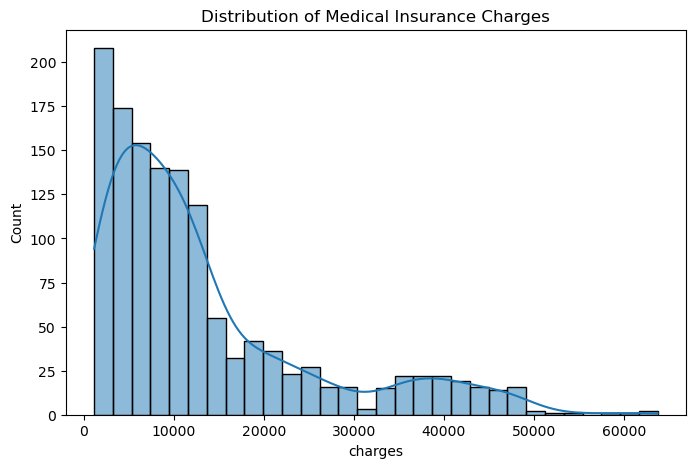

In [6]:
# Distribution of charges
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Insurance Charges")
plt.show()

The distribution is right-skewed, meaning most individuals have lower charges, but a few have very high costs (outliers). These high-cost cases may correspond to smokers or individuals with severe health conditions.

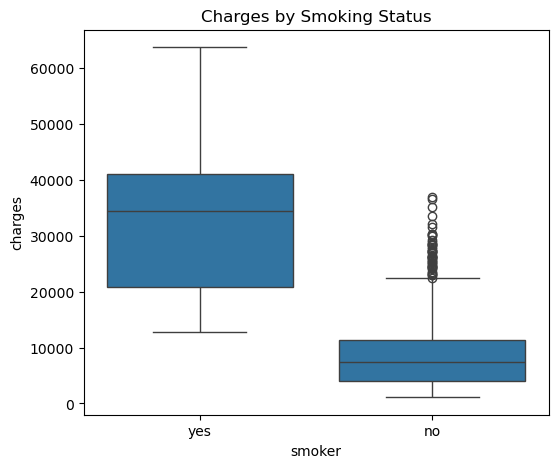

In [8]:
# Charges by Smoking Status
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

Smokers have significantly higher medical charges compared to non-smokers. The median cost for smokers is much higher, confirming smoking is a strong cost driver.

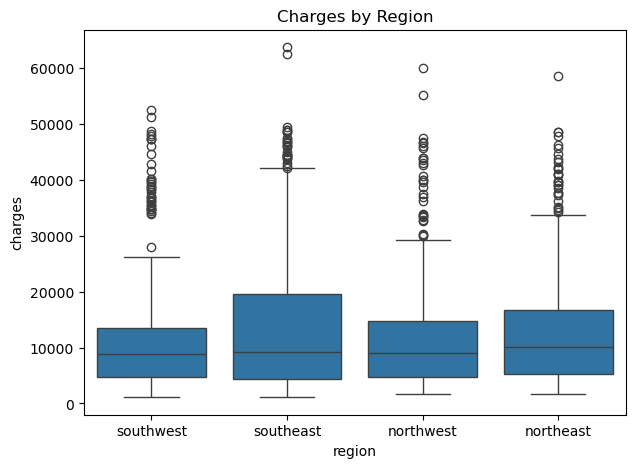

In [10]:
# Charges by Region
plt.figure(figsize=(7,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Charges by Region")
plt.show()

There are no major cost differences across regions, although slight variations exist. This suggests regional factors are less influential compared to smoking or BMI.

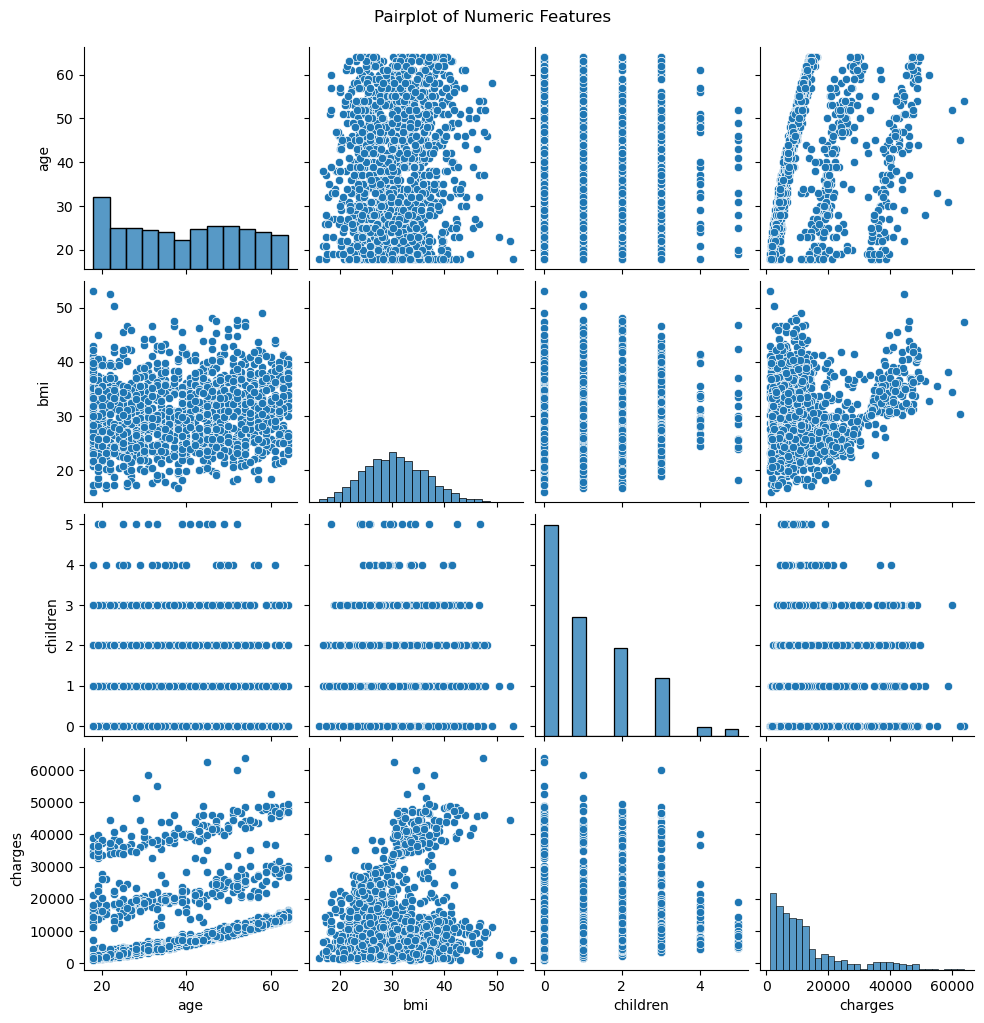

In [12]:
# Pairplot of numeric features
sns.pairplot(df[['age','bmi','children','charges']])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()

Charges increase with "age", particularly for older individuals. "BMI" shows a weak positive trend but with high variance. "Number of children" does not strongly correlate with charges.

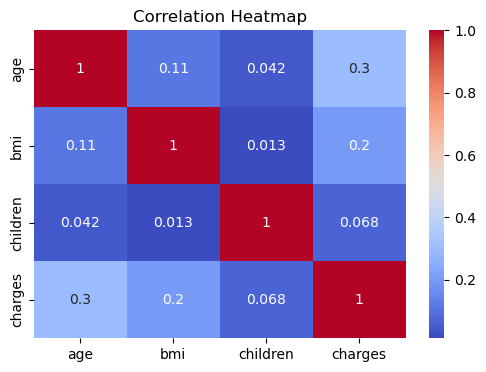

In [14]:
# Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['age','bmi','children','charges']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- "Age" has the highest positive correlation with charges.  
- "BMI" is moderately correlated.  
- "Children" has almost no correlation.  
- These insights align with medical expectations: older age and higher BMI often lead to higher healthcare costs.

### Data Preparation - We separate features and target, encode categorical variables, and split the dataset into training and testing sets.

In [17]:
# Features and target
X = df.drop('charges', axis=1)
y = df['charges']

# One-hot encoding for categorical features
categorical_features = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first'), categorical_features)],
    remainder='passthrough'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Model Training & Evaluation

We train three models:  
- Linear Regression(baseline)  
- Random Forest Regressor(tree-based model)  
- XGBoost Regressor(boosting algorithm)  

In [19]:
# Model dictionary
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0)
}

# Train & evaluate models
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

results_df = pd.DataFrame(results)
results_df

,Model,R2 Score,RMSE,MAE
0,Linear Regression,0.783593,5796.284659,4181.194474
1,Random Forest,0.864182,4591.897971,2561.664977
2,XGBoost,0.852054,4792.540143,2696.769674


- Linear Regression achieved an R² of 0.78, showing it explains about 78% of the variance in charges but has higher error metrics.  
- Random Forest achieved the best performance with an R² of 0.86 and the lowest RMSE and MAE, indicating strong predictive ability.  
- XGBoost also performed well with an R² of 0.85, slightly below Random Forest but still much better than Linear Regression. 

Conclusion from Modeling:

- Tree-based models (Random Forest and XGBoost) capture complex relationships in the data more effectively than Linear Regression.  
- Random Forest is selected as the best-performing model for this dataset because it has the highest accuracy and lowest prediction error.